# ⚔️ DSWA: Nossa Primeira Competição Kaggle!

Bem-vindos ao nosso primeiro desafio prático! Hoje vamos participar da competição **Predict Customer Churn** no Kaggle.

**O Problema:** Uma empresa de telecomunicações quer saber quais clientes vão cancelar a assinatura (o que chamamos de *Churn*). Descobrir isso antes que o cliente vá embora permite que a empresa ofereça descontos ou vantagens para mantê-lo.

**Nosso Objetivo:** Ensinar uma Inteligência Artificial a olhar para o histórico dos clientes e prever a probabilidade de eles cancelarem o serviço!

Vamos fazer isso em 6 passos simples.

## Passo 1: Preparando a Caixa de Ferramentas 🧰

Antes de construir uma casa, precisamos de tijolos e cimento. No Python, usamos "bibliotecas", que são pacotes de códigos já prontos que nos ajudam a trabalhar com dados, criar gráficos e treinar a IA.

In [9]:
# Importando nossas bibliotecas e ferramentas:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
# from sklearn.linear_model import LogisticRegression

## Passo 2: Conhecendo Nossos Dados 🔍
Vamos carregar o arquivo train.csv (os dados dos clientes que sabemos se cancelaram ou não) e dar uma olhada neles.

In [2]:
PATH = './dataset/'
treino = pd.read_csv(PATH + 'train.csv')
teste = pd.read_csv(PATH + 'test.csv')

display(treino.head().style.hide(axis="index"))

id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.100000,1653.850000,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.500000,3778.200000,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.400000,5841.350000,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.700000,70.700000,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.450000,70.450000,Yes


In [3]:
# Estatísticas descritivas do DataFrame
treino.describe(include='all')

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,594194.000000,594194,594194.000000,594194,594194,594194.000000,594194,594194,594194,594194,...,594194,594194,594194,594194,594194,594194,594194,594194.000000,594194.000000,594194
unique,NaN,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,NaN,Female,NaN,Yes,No,NaN,Yes,No,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,NaN,298738,NaN,309554,414362,NaN,557893,283384,272386,289474,...,247377,288571,240301,241435,298918,365579,215372,NaN,NaN,460377
mean,297096.500000,NaN,0.114102,NaN,NaN,36.577258,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.866223,2494.377057,NaN
std,171529.177263,NaN,0.317936,NaN,NaN,25.061922,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.067444,2353.916710,NaN
min,0.000000,NaN,0.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,148548.250000,NaN,0.000000,NaN,NaN,12.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.900000,639.650000,NaN
50%,297096.500000,NaN,0.000000,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.100000,1433.650000,NaN
75%,445644.750000,NaN,0.000000,NaN,NaN,62.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.800000,4263.800000,NaN


In [4]:
# Número de itens nulos por coluna
print(treino.isna().sum())

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


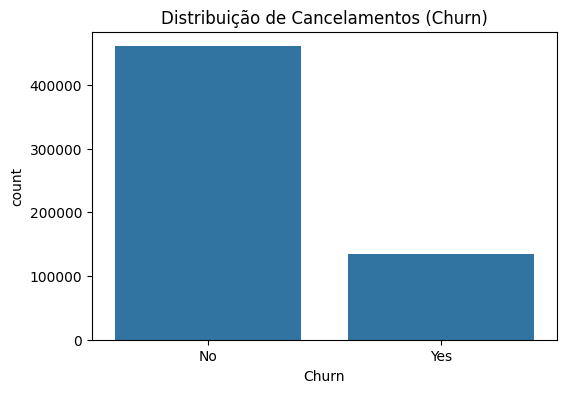

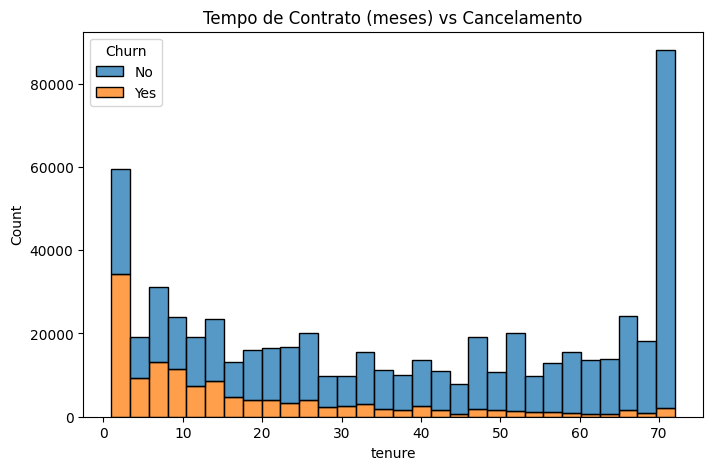

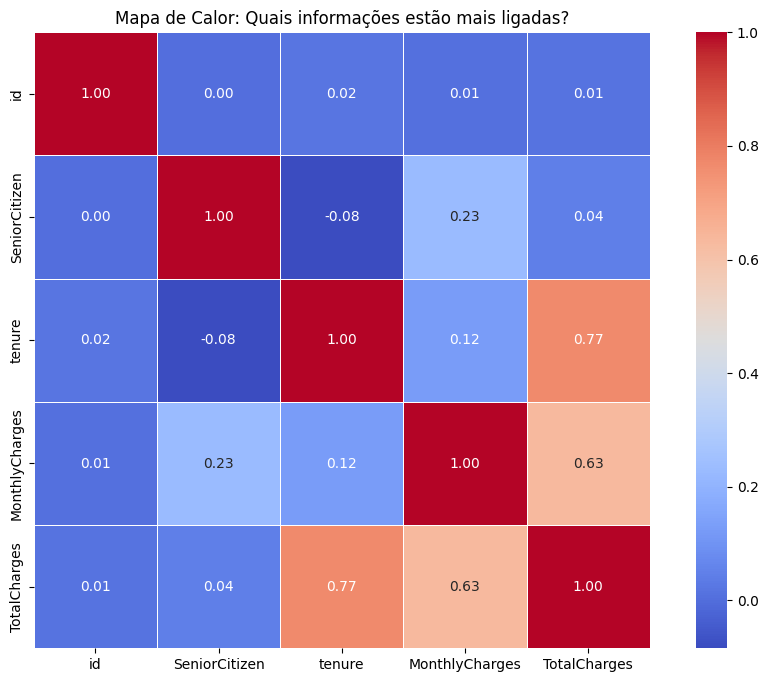

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=treino, x='Churn')
plt.title('Distribuição de Cancelamentos (Churn)')
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(data=treino, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Tempo de Contrato (meses) vs Cancelamento')
plt.show()

colunas_numericas = treino.select_dtypes(include=['number']).columns
correlacao = treino[colunas_numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Mapa de Calor: Quais informações estão mais ligadas?')
plt.show()

## Passo 3: Traduzindo para a Máquina (Pré-processamento) 🤖
O computador é muito rápido, mas ele é "bobo": ele só entende números. Ele não sabe o que é "Fibra Ótica" ou "Feminino". Precisamos transformar todo o texto em números.

In [6]:
# Exemplo pequeno para demonstrar
exemplo_original = treino[['gender', 'InternetService']].head(5)

# Aplicando o One-Hot Encoding no exemplo
exemplo_encoded = pd.get_dummies(exemplo_original)

print("🠖 ANTES (Dados Categóricos)")
display(exemplo_original)

print("\n🠖 DEPOIS (One-Hot Encoding)")
display(exemplo_encoded)

🠖 ANTES (Dados Categóricos)


,gender,InternetService
0,Male,DSL
1,Male,DSL
2,Male,Fiber optic
3,Female,Fiber optic
4,Female,Fiber optic



🠖 DEPOIS (One-Hot Encoding)


,gender_Female,gender_Male,InternetService_DSL,InternetService_Fiber optic
0,False,True,True,False
1,False,True,True,False
2,False,True,False,True
3,True,False,False,True
4,True,False,False,True


In [7]:
X = treino.drop(columns=['id', 'Churn'])
y = treino['Churn']

X_teste_comp = teste.drop(columns=['id'])

X = pd.get_dummies(X, drop_first=True)
X_teste_comp = pd.get_dummies(X_teste_comp, drop_first=True)

X, X_teste_comp = X.align(X_teste_comp, join='inner', axis=1)

print("Dados traduzidos para números com sucesso!")
display(X.head())

Dados traduzidos para números com sucesso!


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,29,60.10,1653.85,True,True,True,True,False,False,...,False,False,False,False,True,False,True,False,False,True
1,0,58,69.50,3778.20,True,True,True,True,False,False,...,False,True,False,False,False,True,False,True,False,False
2,0,58,100.40,5841.35,True,True,False,True,False,True,...,False,True,False,True,False,False,True,False,True,False
3,0,1,69.70,70.70,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
4,0,1,70.45,70.45,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


## Passo 4: O Treinamento (Machine Learning) 🧠
Antes de colocar nosso modelo para fazer a prova do Kaggle, precisamos testá-lo em casa.
Para isso, vamos separar nossos dados de treino: 80% para a IA estudar, e 20% para a gente fazer um simulado.

Por que separamos dados para o simulado? Porque se a IA estudar todas as questões, ela pode simplesmente 'decorar' as respostas em vez de aprender a lógica. O simulado com questões que ela nunca viu garante que ela realmente aprendeu a matéria!

Neste notebook, vamos usar o **Random Forest** (Floresta Aleatória). Imagine que, em vez de perguntar para um único especialista se o cliente vai cancelar, nós perguntamos para uma equipe de 100 especialistas diferentes e tiramos uma média da opinião deles. É isso que esse algoritmo faz!

In [10]:
X_treino, X_valid, y_treino, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

encode = LabelEncoder()
y_treino = encode.fit_transform(y_treino)

modelo = XGBClassifier(n_estimators=100, random_state=42)

print("Treinando a IA...")
modelo.fit(X_treino, y_treino)
print("Treinamento concluído!")

Treinando a IA...
Treinamento concluído!


## Passo 5: Avaliação do Modelo 📊
O Kaggle vai nos avaliar usando uma métrica chamada **ROC AUC**.

Pense assim: a IA dá uma nota de 0 a 100 para o risco de cada cliente cancelar. O ROC AUC avalia se a IA deu as notas mais altas realmente para as pessoas que cancelaram.
- **Nota 0.50:** A IA está apenas "chutando" (jogando uma moeda).
- **Nota 1.00:** A IA acertou perfeitamente.

In [11]:
previsoes_simulado = modelo.predict_proba(X_valid)[:, 1]

nota_auc = roc_auc_score(y_valid, previsoes_simulado)
print("="*40)
print(f"🎉 NOSSA NOTA NO SIMULADO: {nota_auc:.4f} 🎉")
print("="*40)

🎉 NOSSA NOTA NO SIMULADO: 0.9163 🎉


Lembra dos 100 especialistas do Random Forest? Aqui está o relatório do que eles mais olharam na ficha do cliente para tomar uma decisão. Geralmente, o tempo de contrato (tenure) e o valor da mensalidade e anuidade são os fatores decisivos!

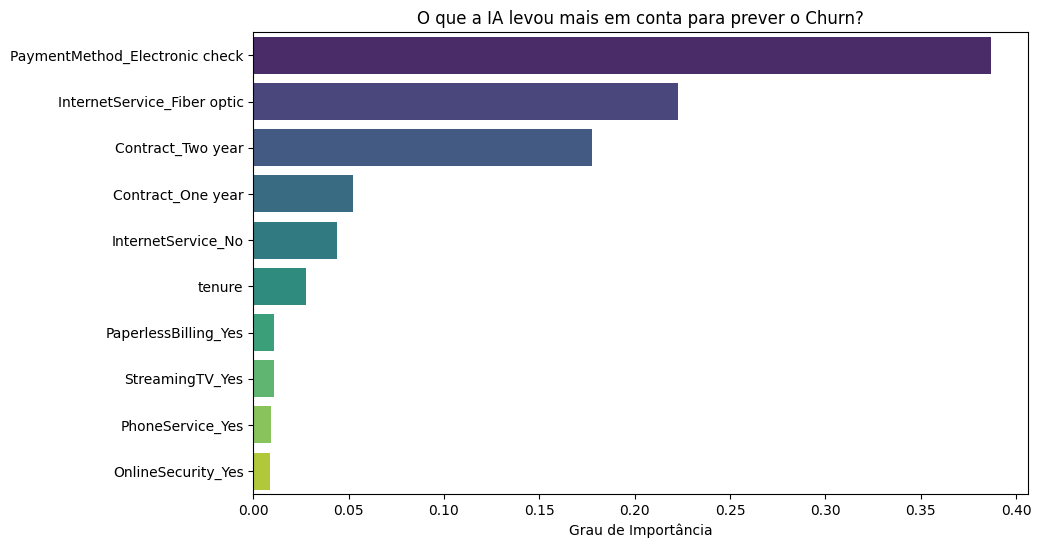

In [12]:
# O que a IA achou mais importante?
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False).head(10) # Pegando as 10 mais importantes

plt.figure(figsize=(10, 6))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, palette='viridis', legend=False)
plt.title('O que a IA levou mais em conta para prever o Churn?')
plt.xlabel('Grau de Importância')
plt.ylabel('')
plt.show()

## Passo 6: Gerando o Arquivo para o Kaggle! 🚀

Agora que vimos que o modelo aprendeu alguma coisa no simulado, vamos usá-lo para prever o arquivo ```test.csv``` oficial do Kaggle.

In [13]:
previsoes_finais = modelo.predict_proba(X_teste_comp)[:, 1]

submissao = pd.DataFrame({
    'id': teste['id'],
    'Churn': previsoes_finais
})

submissao.to_csv('submission.csv', index=False)
print("Arquivo salvo! Agora é só enviar no site do Kaggle!")
# Para submeter, vá na aba 'Submit to competition' na direita e clique no botão 'Submit'

Arquivo salvo! Agora é só enviar no site do Kaggle!


## 💡 Desafio para os Membros: Como subir no Ranking?

Esse notebook é apenas o nosso ponto de partida (nosso "Baseline"). A nota que tiramos não é a máxima possível. O verdadeiro trabalho de um Cientista de Dados começa agora!

Aqui estão algumas estratégias legais (e simples) que vocês podem tentar sozinhos para melhorar o modelo e conseguir uma pontuação maior:

1. **Feature Engineering (Engenharia de Variáveis):** Às vezes, criar uma nova coluna ajuda o modelo. Por exemplo, criar uma coluna "Cobrança Mensal por Mês de Contrato" dividindo as taxas pelo tempo de uso (```tenure```).

2. **Brincar com os Hiperparâmetros:** No ```RandomForestClassifier(n_estimators=100)```, o que acontece se você mudar para ```n_estimators=500```? Ou se limitar a profundidade da árvore de decisão com ```max_depth=5```? O modelo melhora ou piora?

3. **Mudar a IA:** Nós usamos Random Forest. Que tal importar e testar o ```LogisticRegression``` ou o ```XGBoost```? Algoritmos diferentes aprendem de jeitos diferentes.

4. **Balanceando o modelo:** Como temos muito mais dados de quem não cancelou, sua IA pode ter dificuldade em aprender os padrões de quem sai. Que tal testar o parâmetro ```class_weight='balanced'``` para forçar o modelo a dar a mesma importância aos dois grupos?

*Escolha uma dessas ideias, altere o código acima e veja se sua nota sobe! Boa sorte!*